In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import logging
import sys

from pathlib import Path
project_root = Path().resolve().parent
sys.path.append(str(project_root))

from scripts import (
    generate_dataset,
    optuna_search,
    predictions,
    training,
)
from experiments.plotting import _plot_SRE_distribution, view_correlation

from src.utils import configure_logger

import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
logger = logging.getLogger(__name__)
configure_logger(logging.INFO, logging.INFO)

True

In [5]:
model_type="gnn"
epochs = 40
lr = 0.0018760928244666698
loss_type = "huber"   # "mse" | "huber"
batch_size = 32
training_mode = "per_family"  # "global" | "per_family"
family = "haar"  # required if training_mode == "per_family"
target = "sre"
training_data_dir = "../outputs/data/datasets_SRE"
model_save_path = f"../outputs/models/final/{family}_model_{model_type}_{training_mode}.pt"
show_progress=True
show_val_progress=False
log_every_n_batches=10
heartbeat_secs=60.0
epoch_time_warning_secs=600.0
training_scope = "family" if training_mode == "per_family" else "global"
plot_qubits = 6
plot_layers = 100
target_variant = "sre_density"  # "sre" | "sre_density" | "log_sre" | "sqrt_sre"
split = "target"  # "target" | "family"


model_hparams = {
    "gnn_hidden": 32,
    "gnn_heads": 4,
    "global_hidden": 128,
    "reg_hidden": 128,
    "num_layers": 3,
    "dropout_rate": 0.13173830279748305,
}

train_hparams = {
    "weight_decay": 0.0003324725858640221,
    "grad_clip": 1.0289214665544766,
    "early_stopping_patience": 15,
    "early_stopping_min_delta": 0.0,
}

In [22]:
training(
    epochs=epochs,
    lr=lr,
    loss_type=loss_type,
    batch_size=batch_size,
    training_mode=training_mode,
    family=family,
    target=target,
    target_variant=target_variant,
    model_type=model_type,
    model_hparams=model_hparams,
    train_hparams=train_hparams,
    training_data_dir=training_data_dir,
    split=split,
    model_save_path=model_save_path,
    show_progress=True,
    show_val_progress=False,
    log_every_n_batches=10,
    heartbeat_secs=60.0,
    epoch_time_warning_secs=600.0,
)

2026-06-11 18:27:06,478 - GNN.training.runners - INFO - Starting training | model_type=gnn | training_mode=per_family | family=haar | loss_type=huber
2026-06-11 18:27:06,478 - GNN.training.runners - INFO - Training configuration done.
2026-06-11 18:27:06,478 - GNN.training.runners - INFO - Collecting data paths...
2026-06-11 18:27:06,481 - GNN.training.runners - INFO - Found 1 data paths.
2026-06-11 18:27:06,482 - GNN.training.runners - INFO - Data paths collected.
2026-06-11 18:27:06,482 - GNN.training.runners - INFO - Building loaders and model for model_type=gnn...
2026-06-11 18:27:48,140 - GNN.training.runners - INFO - Loaders and model built.
2026-06-11 18:27:48,142 - GNN.training.runners - INFO - Starting training...
2026-06-11 18:27:48,142 - GNN.training.train - INFO - Using device: cuda
2026-06-11 18:27:48,146 - GNN.training.train - INFO - -------- EPOCH 001 --------


2026-06-11 18:28:45,876 - GNN.training.train - INFO - Training complete (57.7s) | running validation...


2026-06-11 18:28:51,337 - GNN.training.train - INFO - Losses | train 0.031896 | val 0.028296 | lr 1.88e-03 | time train=57.7s val=5.5s total=63.2s
2026-06-11 18:28:51,339 - GNN.training.train - INFO - -------- EPOCH 002 --------


2026-06-11 18:29:50,589 - GNN.training.train - INFO - Training complete (59.2s) | running validation...


2026-06-11 18:29:55,599 - GNN.training.train - INFO - Losses | train 0.029416 | val 0.027634 | lr 1.88e-03 | time train=59.2s val=5.0s total=64.3s
2026-06-11 18:29:55,602 - GNN.training.train - INFO - -------- EPOCH 003 --------


...

2026-06-11 18:52:05,187 - GNN.training.train - INFO - Losses | train 0.028319 | val 0.027717 | lr 9.38e-04 | time train=79.1s val=6.5s total=85.6s
2026-06-11 18:52:05,187 - GNN.training.train - INFO - -------- EPOCH 020 --------


Epoch 20/40:  77%|███████▋  | 623/804 [01:00<00:18,  9.54it/s, loss=0.0282, graphs=2e+4] 

2026-06-11 18:53:05,212 - GNN.training.train - INFO - [Heartbeat] Epoch 20 batch 624/804 | loss 0.028156 | elapsed 60.0s | graphs 19968


2026-06-11 18:53:19,189 - GNN.training.train - INFO - Training complete (74.0s) | running validation...


2026-06-11 18:53:25,717 - GNN.training.train - INFO - Losses | train 0.028302 | val 0.027733 | lr 9.38e-04 | time train=74.0s val=6.5s total=80.5s
2026-06-11 18:53:25,717 - GNN.training.train - INFO - Early stopping at epoch 020 | best val 0.027286 | patience exhausted (10/10)
2026-06-11 18:54:06,092 - GNN.training.runners - INFO - Training complete.
2026-06-11 18:54:06,151 - GNN.training.runners - INFO - Saved model checkpoint to ..\outputs\models\final\haar_model_gnn_per_family.pt
2026-06-11 18:54:06,181 - scripts.train_model - INFO - Final test loss: 0.028005
2026-06-11 18:54:06,181 - scripts.train_model - INFO - Test R2 score: 0.1408
2026-06-11 18:54:06,181 - scripts.train_model - INFO - Validation R2 score: 0.1505
2026-06-11 18:54:06,183 - scripts.train_model - INFO - Training R2 score: 0.0000


In [6]:
training_scope = "family" if training_mode == "per_family" else "global"
model_save_path = f"../outputs/models/final/gnn_huber_quansistor.pt"
predictions(
    model_path=model_save_path,
    model_kind=model_type,
    training_scope=training_scope,
    target_variant=target_variant,
    loss_type=loss_type,
    model_family=family,
    dataset_root=training_data_dir,
    dataset_family=family,
    batch_size=batch_size,
    global_feature_variant="binned",
    node_feature_backend_variant=None,
    plot_n_layers=plot_layers,
    plot_n_qubits=plot_qubits,
    split_by_family=True,
    show_progress=True,
)

2026-06-12 18:03:06,916 - scripts.predictions - INFO - Loading checkpoint: ../outputs/models/final/gnn_huber_quansistor.pt
2026-06-12 18:03:07,062 - scripts.predictions - INFO - Found 1 prediction files
Predicting (gnn): 100%|██████████| 3905/3905 [06:43<00:00,  9.69batch/s]
2026-06-12 18:10:38,557 - scripts.predictions - INFO - Saved 124950 predictions to ../outputs/predictions/family/gnn_predictions_haar.csv
2026-06-12 18:10:38,756 - scripts.predictions - INFO - Saved fixed-layer plot to ../outputs/figures/predictions/family/gnn_pred_layers_haar.png
2026-06-12 18:10:38,924 - scripts.predictions - INFO - Saved fixed-qubit plot to ../outputs/figures/predictions/family/gnn_pred_qubits_haar.png


In [11]:
from GNN.training.utils import to_scalar

df = pd.read_csv(f"../outputs/predictions/family/gnn_predictions_quansistor.csv")
cols_to_fix = ["n_qubits", "n_layers", "seed"]

for col in cols_to_fix:
    df[col] = df[col].apply(to_scalar).astype(int)

nq=plot_qubits
nl=plot_layers
df["prediction"] = df["prediction"] * nq
view_correlation(
    df,
    nq=plot_qubits,
    nl=plot_layers,
    col_x="target",
    col_y="prediction",
)
df = df[(df["n_qubits"] == plot_qubits) & (df["n_layers"] == plot_layers)]
plt.figure(figsize=(8, 6))
plt.scatter(df["target"], df["prediction"], alpha=0.7)
plt.plot([df["target"].min(), df["target"].max()], [df["target"].min(), df["target"].max()], "r--")  # y=x line
plt.xlabel("True SRE")
plt.ylabel("Predicted SRE")
plt.title("True vs Predicted SRE for Quansistor Family (GNN Model)")

FileNotFoundError: [Errno 2] No such file or directory: '../outputs/predictions/family/gnn_predictions_quansistor.csv'

In [17]:
model_type="gnn"
epochs = 40
lr = 0.0018760928244666698
loss_type = "huber"   # "mse" | "huber"
batch_size = 32
training_mode = "per_family"  # "global" | "per_family"
family = "random"  # required if training_mode == "per_family"
target = "sre"
training_data_dir = "../outputs/data/datasets_SRE"
model_save_path = f"../outputs/models/final/{family}_model_{model_type}_{training_mode}.pt"
show_progress=True
show_val_progress=False
log_every_n_batches=10
heartbeat_secs=60.0
epoch_time_warning_secs=600.0
training_scope = "family" if training_mode == "per_family" else "global"
plot_qubits = 6
plot_layers = 100
target_variant = "sre"  # "sre" | "sre_density" | "log_sre" | "sqrt_sre"
split = "target"  # "target" | "family"


model_hparams = {
    "gnn_hidden": 32,
    "gnn_heads": 4,
    "global_hidden": 128,
    "reg_hidden": 128,
    "num_layers": 3,
    "dropout_rate": 0.13173830279748305,
}

train_hparams = {
    "weight_decay": 0.0003324725858640221,
    "grad_clip": 1.0289214665544766,
    "early_stopping_patience": 15,
    "early_stopping_min_delta": 0.0,
}

In [18]:
training(
    epochs=epochs,
    lr=lr,
    loss_type=loss_type,
    batch_size=batch_size,
    training_mode=training_mode,
    family=family,
    target=target,
    target_variant=target_variant,
    model_type=model_type,
    model_hparams=model_hparams,
    train_hparams=train_hparams,
    training_data_dir=training_data_dir,
    split=split,
    model_save_path=model_save_path,
    show_progress=True,
    show_val_progress=False,
    log_every_n_batches=10,
    heartbeat_secs=60.0,
    epoch_time_warning_secs=600.0,
)

2026-06-11 16:16:39,384 - GNN.training.runners - INFO - Starting training | model_type=gnn | training_mode=per_family | family=random | loss_type=huber
2026-06-11 16:16:39,384 - GNN.training.runners - INFO - Training configuration done.
2026-06-11 16:16:39,384 - GNN.training.runners - INFO - Collecting data paths...
2026-06-11 16:16:39,387 - GNN.training.runners - INFO - Found 1 data paths.
2026-06-11 16:16:39,387 - GNN.training.runners - INFO - Data paths collected.
2026-06-11 16:16:39,387 - GNN.training.runners - INFO - Building loaders and model for model_type=gnn...
2026-06-11 16:18:07,542 - GNN.training.runners - INFO - Loaders and model built.
2026-06-11 16:18:07,542 - GNN.training.runners - INFO - Starting training...
2026-06-11 16:18:07,543 - GNN.training.train - INFO - Using device: cuda
2026-06-11 16:18:07,547 - GNN.training.train - INFO - -------- EPOCH 001 --------


Epoch 1/40:  47%|████▋     | 374/804 [01:00<01:18,  5.48it/s, loss=0.8324, graphs=12000]

2026-06-11 16:19:07,551 - GNN.training.train - INFO - [Heartbeat] Epoch 1 batch 375/804 | loss 0.832425 | elapsed 60.0s | graphs 12000


Epoch 1/40:  93%|█████████▎| 744/804 [02:00<00:09,  6.64it/s, loss=0.7520, graphs=23840]

2026-06-11 16:20:07,690 - GNN.training.train - INFO - [Heartbeat] Epoch 1 batch 745/804 | loss 0.751997 | elapsed 120.1s | graphs 23840


...

2026-06-11 18:03:25,178 - GNN.training.train - INFO - [Heartbeat] Epoch 40 batch 348/804 | loss 0.572640 | elapsed 60.0s | graphs 11136


Epoch 40/40:  87%|████████▋ | 696/804 [02:00<00:17,  6.06it/s, loss=0.5685, graphs=22304]

2026-06-11 18:04:25,296 - GNN.training.train - INFO - [Heartbeat] Epoch 40 batch 697/804 | loss 0.568546 | elapsed 120.1s | graphs 22304


2026-06-11 18:04:43,613 - GNN.training.train - INFO - Training complete (138.4s) | running validation...


2026-06-11 18:04:57,183 - GNN.training.train - INFO - Losses | train 0.570184 | val 0.576454 | lr 2.35e-04 | time train=138.4s val=13.6s total=152.0s
2026-06-11 18:06:36,618 - GNN.training.runners - INFO - Training complete.
2026-06-11 18:06:36,700 - GNN.training.runners - INFO - Saved model checkpoint to ..\outputs\models\final\random_model_gnn_per_family.pt
2026-06-11 18:06:36,737 - scripts.train_model - INFO - Final test loss: 0.550861
2026-06-11 18:06:36,738 - scripts.train_model - INFO - Test R2 score: 0.5820
2026-06-11 18:06:36,738 - scripts.train_model - INFO - Validation R2 score: 0.6060
2026-06-11 18:06:36,739 - scripts.train_model - INFO - Training R2 score: 0.0000


In [19]:
training_scope = "family" if training_mode == "per_family" else "global"
predictions(
    model_path=model_save_path,
    model_kind=model_type,
    training_scope=training_scope,
    target_variant=target_variant,
    loss_type=loss_type,
    model_family=family,
    dataset_root=training_data_dir,
    dataset_family=family,
    batch_size=batch_size,
    global_feature_variant="binned",
    node_feature_backend_variant=None,
    plot_n_layers=plot_layers,
    plot_n_qubits=plot_qubits,
    split_by_family=True,
    show_progress=True,
)

2026-06-11 18:06:37,115 - scripts.predictions - INFO - Loading checkpoint: ../outputs/models/final/random_model_gnn_per_family.pt
2026-06-11 18:06:37,126 - scripts.predictions - INFO - Found 1 prediction files
Predicting (gnn): 100%|██████████| 3905/3905 [12:27<00:00,  5.23batch/s]
2026-06-11 18:19:42,838 - scripts.predictions - INFO - Saved 124950 predictions to ../outputs/predictions/family/gnn_predictions_random.csv
2026-06-11 18:19:42,951 - scripts.predictions - INFO - Saved fixed-layer plot to ../outputs/figures/predictions/family/gnn_pred_layers_random.png
2026-06-11 18:19:43,078 - scripts.predictions - INFO - Saved fixed-qubit plot to ../outputs/figures/predictions/family/gnn_pred_qubits_random.png


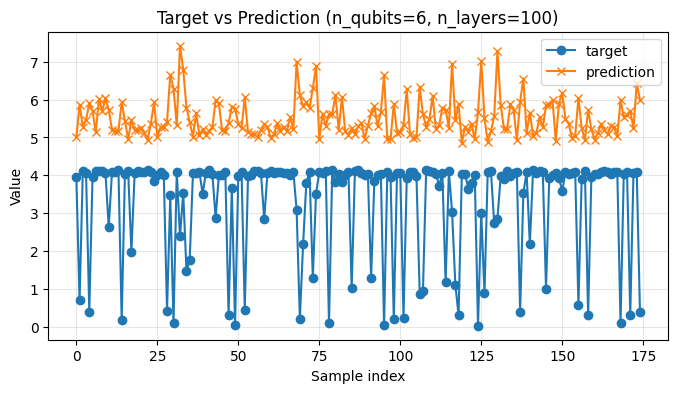

Pearson r = -0.4095


Text(0.5, 1.0, 'True vs Predicted SRE for Clifford Family (GNN Model)')

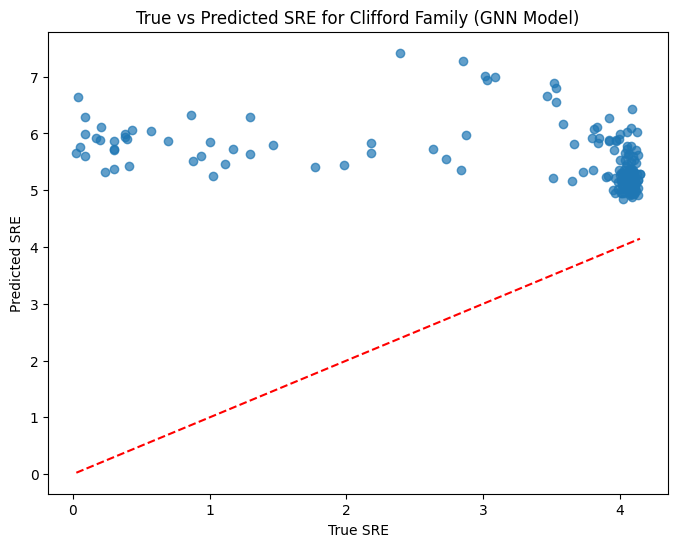

In [20]:

df = pd.read_csv(f"../outputs/predictions/{training_scope}/{model_type}_predictions_{family}.csv")
cols_to_fix = ["n_qubits", "n_layers", "seed"]

for col in cols_to_fix:
    df[col] = df[col].apply(to_scalar).astype(int)

view_correlation(
    df,
    nq=plot_qubits,
    nl=plot_layers,
    col_x="target",
    col_y="prediction",
)
df = df[(df["n_qubits"] == plot_qubits) & (df["n_layers"] == plot_layers)]
plt.figure(figsize=(8, 6))
plt.scatter(df["target"], df["prediction"], alpha=0.7)
plt.plot([df["target"].min(), df["target"].max()], [df["target"].min(), df["target"].max()], "r--")  # y=x line
plt.xlabel("True SRE")
plt.ylabel("Predicted SRE")
plt.title("True vs Predicted SRE for Clifford Family (GNN Model)")